In [1]:
#import Libraries

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

In [2]:
#Load Dataset

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "D:/CNN/dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64, 64),
    batch_size=32,
    color_mode='grayscale'
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "D:/CNN/dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64, 64),
    batch_size=32,
    color_mode='grayscale'
)

class_names = train_data.class_names
num_classes = len(class_names)     

Found 346 files belonging to 11 classes.
Using 277 files for training.
Found 346 files belonging to 11 classes.
Using 69 files for validation.


In [3]:
train_data = train_data.shuffle(1000)

C:\Users\User\anaconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2541 (\N{BENGALI DIGIT SEVEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2535 (\N{BENGALI DIGIT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2542 (\N{BENGALI DIGIT EIGHT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2540 (\N{BENGALI DIGIT SIX}) missing from current font.
  fig.canvas.print_figur

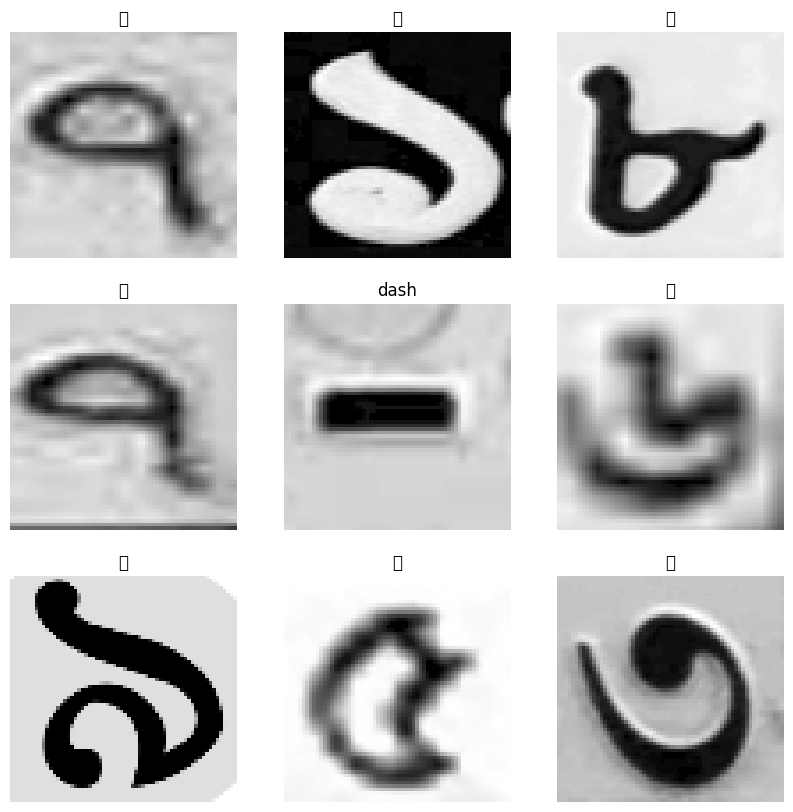

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [5]:
train_data = train_data.map(lambda x, y: (x/255.0, y))
val_data = val_data.map(lambda x, y: (x/255.0, y))

In [6]:
layers.Dense(len(class_names), activation='softmax')

In [7]:
#CNN Model Build


model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])


In [8]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Model Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                                                                 
 dense_1 (Dense)             (None, 64)                8

In [10]:
# Train Model

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

Epoch 1/25
9/9 [==============================] - 3s 218ms/step - loss: 2.3456 - accuracy: 0.1336 - val_loss: 2.2485 - val_accuracy: 0.3768
Epoch 2/25
9/9 [==============================] - 1s 150ms/step - loss: 2.1201 - accuracy: 0.3682 - val_loss: 2.0247 - val_accuracy: 0.5652
Epoch 3/25
9/9 [==============================] - 2s 152ms/step - loss: 1.8176 - accuracy: 0.7076 - val_loss: 1.6655 - val_accuracy: 0.7826
Epoch 4/25
9/9 [==============================] - 1s 147ms/step - loss: 1.3900 - accuracy: 0.8014 - val_loss: 1.2999 - val_accuracy: 0.7681
Epoch 5/25
9/9 [==============================] - 1s 152ms/step - loss: 0.9680 - accuracy: 0.8484 - val_loss: 0.9178 - val_accuracy: 0.8696
Epoch 6/25
9/9 [==============================] - 1s 145ms/step - loss: 0.6586 - accuracy: 0.9170 - val_loss: 0.7470 - val_accuracy: 0.8986
Epoch 7/25
9/9 [==============================] - 2s 158ms/step - loss: 0.5229 - accuracy: 0.9061 - val_loss: 0.6770 - val_accuracy: 0.8986
Epoch 8/25
9/9 [====

In [11]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.1335740089416504, 0.36823105812072754, 0.7075812220573425, 0.8014440536499023, 0.8483754396438599, 0.916967511177063, 0.9061371684074402, 0.9205776453018188, 0.916967511177063, 0.9241877198219299, 0.9422382712364197, 0.9422382712364197, 0.9494584798812866, 0.9566786885261536, 0.9638988971710205, 0.9711191058158875, 0.9675090312957764, 0.9747292399406433, 0.9783393740653992, 0.9891696572303772, 0.9891696572303772, 0.9891696572303772, 0.9891696572303772, 0.9855595827102661, 0.9855595827102661]
[0.37681159377098083, 0.5652173757553101, 0.782608687877655, 0.7681159377098083, 0.8695651888847351, 0.8985507488250732, 0.8985507488250732, 0.9130434989929199, 0.8840579986572266, 0.9130434989929199, 0.8695651888847351, 0.8840579986572266, 0.9130434989929199, 0.8985507488250732, 0.9130434989929199, 0.9130434989929199, 0.8840579986572266, 0.8985507488250732, 0.8985507488250732, 0.8985507488250732, 0.8985507488250732, 0.8840579986572266, 0.8985507488250732, 0.8840579986572266, 0.8985507488250732]

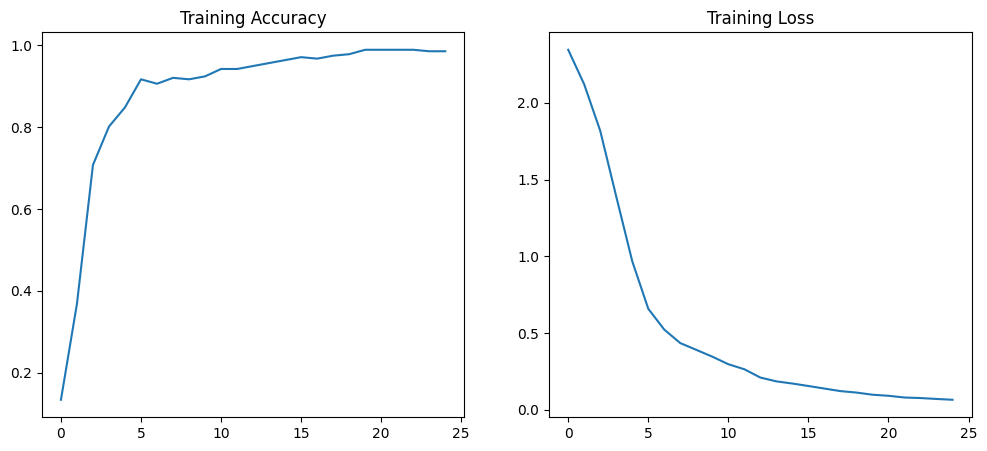

In [12]:
#Plot Accuracy & Loss

acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc)
plt.title('Training Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss)
plt.title('Training Loss')

plt.show()

In [13]:
# Test Prediction Function

def predict_character(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64,64))
    img = img / 255.0
    img = np.reshape(img, (1,64,64,1))

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    return class_names[class_index]   # ✅ FIXED

In [14]:
# Test

print(predict_character("D:/CNN/Test/test5.png"))

1/1 [==============================] - 0s 199ms/step
৫


# 2nd part

Image shape: (134, 651)
Pixel min: 53 | max: 249 | mean: 175.651064951739


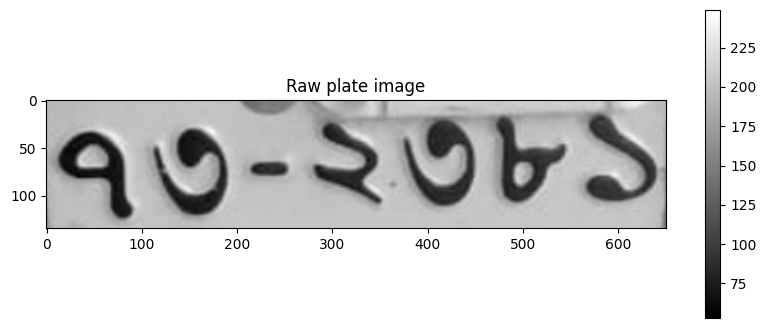

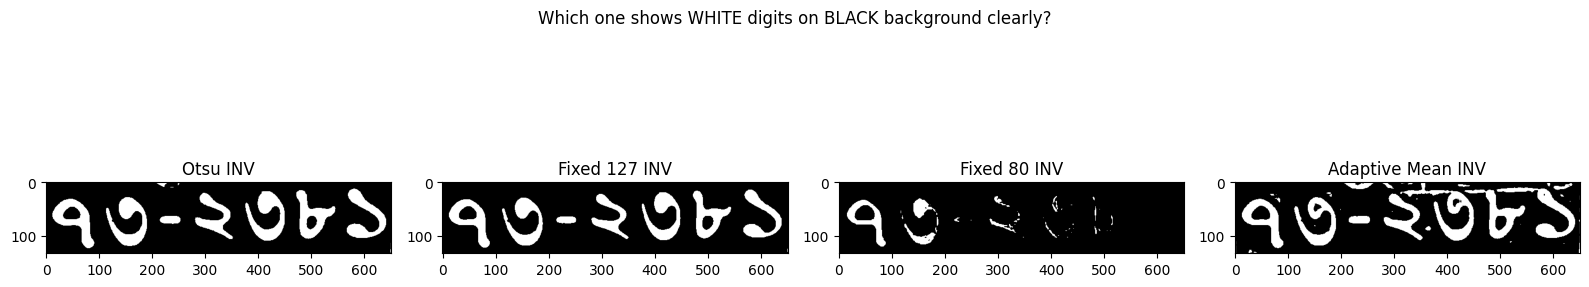

In [15]:
# ============================================================
# STEP 1: SHOW RAW TEST PLATE IMAGE 
# ============================================================

img_path = "D:/CNN/Test/car3.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Pixel min:", img.min(), "| max:", img.max(), "| mean:", img.mean())

plt.figure(figsize=(10, 4))
plt.imshow(img, cmap='gray')
plt.title("Raw plate image")
plt.colorbar()
plt.show()

# Try ALL threshold methods so we can see which one shows digits clearly
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

_, t1 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, t2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
_, t3 = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY_INV)
t4    = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 21, 5)

axes[0].imshow(t1, cmap='gray'); axes[0].set_title("Otsu INV")
axes[1].imshow(t2, cmap='gray'); axes[1].set_title("Fixed 127 INV")
axes[2].imshow(t3, cmap='gray'); axes[2].set_title("Fixed 80 INV")
axes[3].imshow(t4, cmap='gray'); axes[3].set_title("Adaptive Mean INV")

plt.suptitle("Which one shows WHITE digits on BLACK background clearly?")
plt.tight_layout()
plt.show()

Model class order: ['dash', '০', '১', '২', '৩', '৪', '৫', '৬', '৭', '৮', '৯']
Characters detected: 7


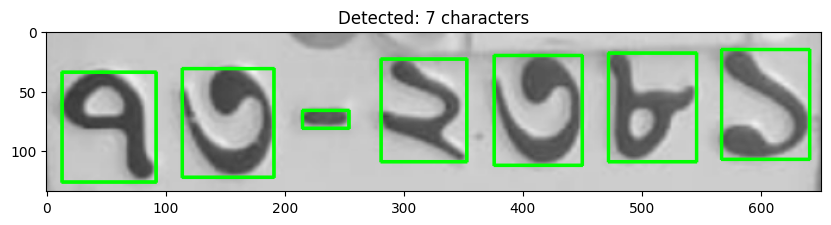

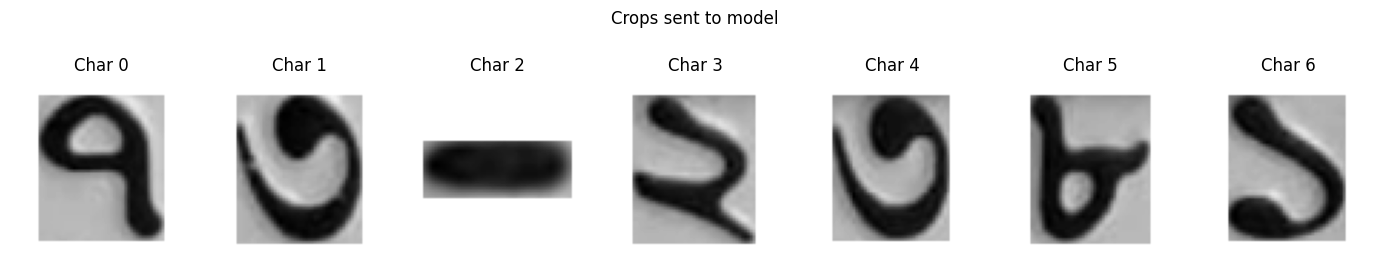

Char 0: '৭'  (confidence: 1.00)
Char 1: '৩'  (confidence: 0.96)
Char 2: '-'  (confidence: 1.00)
Char 3: '২'  (confidence: 0.99)
Char 4: '৩'  (confidence: 0.85)
Char 5: '৮'  (confidence: 1.00)
Char 6: '১'  (confidence: 1.00)

✅ Predicted Plate: ৭৩-২৩৮১


In [16]:
# ============================================================
# FULL CAR PLATE PREDICTION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# class_names comes from Part 1 (train_data.class_names)
print("Model class order:", class_names)

def get_label(class_name):
    if class_name == 'dash':
        return '-'
    return class_name  # already Bangla

# ============================================================
# LOAD IMAGE & THRESHOLD
# ============================================================

img_path = "D:/CNN/Test/car3.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
characters = []
img_h, img_w = img.shape

# ============================================================
# CONTOUR FILTERING
# ============================================================

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    aspect = w / float(h)
    rel_h = h / float(img_h)

    # Normal digit condition
    is_digit = (area > 300
                and w > 15 and h > 25
                and aspect < 2.5
                and rel_h > 0.30
                and rel_h < 0.98)

    # Special dash condition
    is_dash = (area > 150
               and aspect > 1.5
               and rel_h < 0.25
               and rel_h > 0.05
               and w > 25)

    if is_digit or is_dash:
        # Crop from original grayscale (black digits on white — matches training)
        char = img[y:y+h, x:x+w]

        # White canvas
        canvas = np.ones((64, 64), dtype=np.uint8) * 255
        scale = min(52 / w, 52 / h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        char_resized = cv2.resize(char, (new_w, new_h))
        x_off = (64 - new_w) // 2
        y_off = (64 - new_h) // 2
        canvas[y_off:y_off+new_h, x_off:x_off+new_w] = char_resized

        cv2.rectangle(img_color, (x, y), (x+w, y+h), (0, 255, 0), 2)
        characters.append((x, canvas))

# Sort left to right
characters = sorted(characters, key=lambda item: item[0])
characters_imgs = [char for (_, char) in characters]

print(f"Characters detected: {len(characters_imgs)}")

# Show detection boxes
plt.figure(figsize=(10, 4))
plt.imshow(img_color)
plt.title(f"Detected: {len(characters_imgs)} characters")
plt.show()

# Show individual crops
fig, axes = plt.subplots(1, len(characters_imgs), figsize=(14, 3))
if len(characters_imgs) == 1:
    axes = [axes]
for i, char in enumerate(characters_imgs):
    axes[i].imshow(char, cmap='gray')
    axes[i].set_title(f"Char {i}")
    axes[i].axis('off')
plt.suptitle("Crops sent to model")
plt.tight_layout()
plt.show()

# ============================================================
# PREDICTION
# ============================================================

plate_text = ""

for i, char in enumerate(characters_imgs):
    char_norm = char / 255.0
    char_input = np.reshape(char_norm, (1, 64, 64, 1))

    prediction = model.predict(char_input, verbose=0)
    index = np.argmax(prediction)
    confidence = prediction[0][index]

    folder_label = class_names[index]
    bangla_label = get_label(folder_label)

    print(f"Char {i}: '{bangla_label}'  (confidence: {confidence:.2f})")
    plate_text += bangla_label

print("\n✅ Predicted Plate:", plate_text)